# Statement
This project applies the data science process to real-world rainfall data. It involves loading, cleaning, and preparing raw climate data before conducting exploratory analysis. Through systematic data processing and visualization, the aim is to uncover patterns and trends in rainfall over time.

# Task 1: Data Preparation


In [11]:
import pandas as pd
rain_df = pd.read_csv('Data.csv', sep=',', decimal='.', header=0)
print(rain_df.head())
print(rain_df.dtypes)
print(rain_df.shape)

   Year Month Day  Rainfall amount (millimetres)
0  2013     6   2                            5.0
1  2013     6   3                            0.2
2  2013     6   4                            0.2
3  2013     6   5                            0.0
4  2013     6   6                            0.0
Year                               int64
Month                             object
Day                               object
Rainfall amount (millimetres)    float64
dtype: object
(3865, 4)


In [12]:
# Check for NA data and remove rows
na_rows = rain_df[rain_df.isna().any(axis=1)]
rain_df = rain_df.dropna(axis=0).reset_index(drop=True)
print(na_rows)

      Year Month  Day  Rainfall amount (millimetres)
739   2015     6   11                            NaN
1736  2018     3  NaN                            0.0
1955  2018    10    9                            NaN
1956  2018    10   10                            NaN
2067  2019   NaN   29                            0.0
2958  2021     7    8                            NaN
2959  2021     7    9                            NaN


In [ ]:
# Convert 'Year', 'Month', 'Day' to string and combine into a single datetime object and check for unresonable date
rain_df[['Year', 'Month', 'Day']] = rain_df[['Year', 'Month', 'Day']].astype(str)
rain_df['date'] = pd.to_datetime(rain_df[['Year', 'Month', 'Day']], errors='coerce')

# Remove out of range dates
out_of_range = rain_df[(rain_df['date'] < '2013-01-01') | (rain_df['date'] > '2023-12-31')]
rain_df = rain_df[(rain_df['date'] >= '2013-01-01') & (rain_df['date'] <= '2023-12-31')].reset_index(drop=True)
print(out_of_range)





      Year Month Day  Rainfall amount (millimetres)       date
1403  2027     4   6                            0.0 2027-04-06


In [15]:
duplicate_dates = rain_df[rain_df['date'].duplicated()]
print("Duplicate dates:", len(duplicate_dates))
print(duplicate_dates)

Duplicate dates: 0
Empty DataFrame
Columns: [Year, Month, Day, Rainfall amount (millimetres), date]
Index: []


In [ ]:
duplicate_dates = rain_df[rain_df['date'].duplicated()]
print("Duplicate dates:", len(duplicate_dates))
print(duplicate_dates)



# Check rows where the 'date' column has NaT
rain_df[rain_df['date'].isna()]

# Task 2: Data Exploration

## Task 2.1 
Prepare and convert the data in 2014 as a pandas DataFrame with rows as the days in a month and columns as the months in a year (e.g. row 1 contains the rainfall data in the 1st day of each month; row 2 contains the rainfall data in the 2nd day of each month, ...). Then, explore the highest daily rainfall in each month.


In [66]:
import pandas as pd
df = pd.read_csv('Data_clean.csv', sep=',', decimal='.', header=0)
rain_2014 = df[df['Year'] == 2014]
print(rain_2014.shape)
# Pivot the DataFrame to have 'Day' as rows and 'Month' as columns
rain_pivot = rain_2014.pivot(index='Day', columns='Month', values='Rainfall amount (millimetres)')

# Sort index for better readability
rain_pivot = rain_pivot.sort_index()

print(rain_pivot.head())

(365, 4)
Month   1    2    3    4    5    6    7     8     9    10   11   12
Day                                                                
1      0.0  0.0  0.0  0.0  0.0  3.8  0.4   5.2   0.0  2.6  6.0  0.0
2      5.2  0.0  0.0  0.0  0.0  3.2  0.0  10.6  10.8  0.0  0.2  0.4
3      0.0  0.0  0.0  0.2  1.4  3.4  0.0   0.6   0.2  0.6  0.0  0.0
4      0.0  0.4  0.0  0.0  5.6  1.6  0.0   0.0   0.0  0.2  0.0  9.0
5      0.2  0.0  0.0  0.0  1.8  4.8  0.0   0.0   0.0  0.0  0.0  0.0


Month
1      5.4
2     10.4
3      6.6
4     18.2
5     11.0
6      7.0
7      5.0
8     10.6
9     11.6
10    22.4
11    36.6
12    14.8
dtype: float64


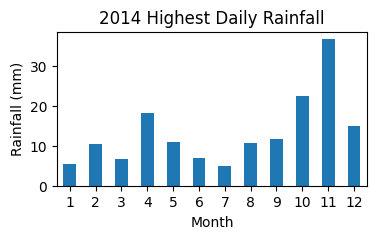

In [123]:
# Get the highest daily rainfall in each month using rain_pivot
max_rainfall_per_month = rain_pivot.max(axis=0)  # Max value in each column (month)
print(max_rainfall_per_month)

import matplotlib.pyplot as plt
max_rainfall_per_month.plot(kind='bar',figsize=(4, 2))
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.title('2014 Highest Daily Rainfall')
plt.xticks(rotation=0)
plt.show()


## Task 2.2 
Explore the data between 2015 and 2017, and analyse them on both a yearly and monthly basis with visualizations.

Year
2015    439.2
2016    599.6
2017    602.0
Name: Rainfall amount (millimetres), dtype: float64


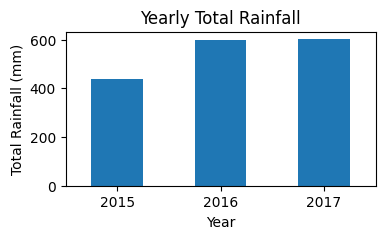

In [68]:
# Filter data for years 2015-2017
rain_2015_2017 = df[(df['Year'] >= 2015) & (df['Year'] <= 2017)]

# Yearly total rainfall (result in series with year as index)
yearly_rainfall = rain_2015_2017.groupby('Year')['Rainfall amount (millimetres)'].sum()
print(yearly_rainfall)

import matplotlib.pyplot as plt
yearly_rainfall.plot(kind='bar',figsize=(4, 2))
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.title('Yearly Total Rainfall')
plt.xticks(rotation=0)
plt.show()


In [80]:
# Monthly total rainfall (across years)
monthly_rainfall = rain_2015_2017.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().reset_index() # Use .reset_index() to convert it into a DataFrame

# monthly_rainfall_pivot = monthly_rainfall.pivot(index='Year', columns='Month', values='Rainfall amount (millimetres)')
print(monthly_rainfall.head())

   Year  Month  Rainfall amount (millimetres)
0  2015      1                           47.4
1  2015      2                           37.8
2  2015      3                           23.0
3  2015      4                           36.8
4  2015      5                           37.6


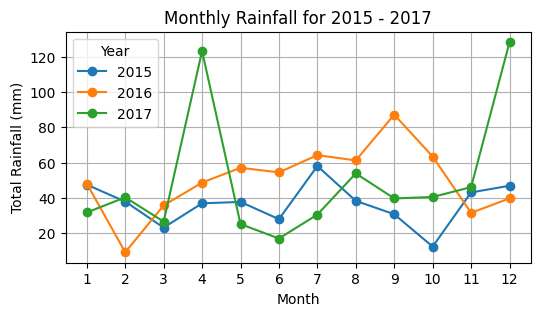

In [118]:
import matplotlib.pyplot as plt

# Pivot the data
monthly_rainfall_pivot = monthly_rainfall.pivot(index='Month', columns='Year', values='Rainfall amount (millimetres)')

# Create the plot
monthly_rainfall_pivot.plot(kind='line', marker='o', figsize=(6,3))
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
plt.title('Monthly Rainfall for 2015 - 2017')
plt.xticks(range(1, 13))  # Ensure x-axis shows months 1-12
plt.legend(title="Year")  # Add a legend for year differentiation
plt.grid(True)  # Add grid for readability
plt.show()

## Task 2.3 
Explore the data, and find the top 3 years with the highest rainfall amount and the top 3 years with the lowest rainfall amount, then compare them.

Year
2013    380.2
2014    432.0
2015    439.2
2016    599.6
2017    602.0
2018    514.4
2019    374.4
2020    786.8
2021    682.6
2022    699.4
2023    574.0
Name: Rainfall amount (millimetres), dtype: float64


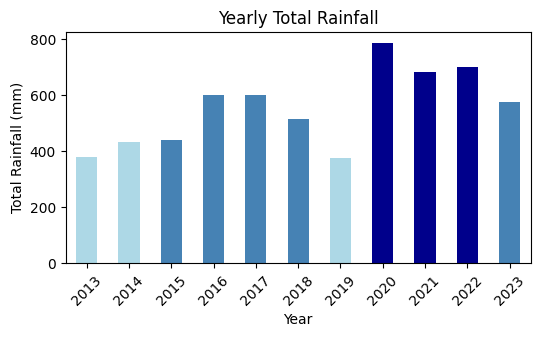

In [156]:
# Yearly total rainfall (series with year as index)
yearly_rainfall = df.groupby('Year')['Rainfall amount (millimetres)'].sum() 
print(yearly_rainfall)

# Sort the data to find the top 3 years with the highest rainfall
top_3_years = yearly_rainfall.sort_values(ascending=False).head(3)
low_3_years = yearly_rainfall.sort_values(ascending=True).head(3)

# Plot the total rainfall by year (use the index which is year to identify)
# ax = yearly_rainfall.plot(kind='bar', figsize=(6, 3), color=['red' if year in top_3_years.index else 'blue' for year in yearly_rainfall.index])

# Assign colors based on year ranking
colors = [
    'darkblue' if year in top_3_years.index else
    'lightblue' if year in low_3_years.index else
    'steelblue' 
    for year in yearly_rainfall.index
]

# Plot the total rainfall by year
yearly_rainfall.plot(kind='bar', figsize=(6, 3), color=colors)

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.title('Yearly Total Rainfall')
plt.xticks(rotation=45)
plt.show()

Year 2020 has the highest total rainfall: 786.8 mm
Year 2019 has the lowest total rainfall: 374.4 mm
The difference between the highest and lowest total rainfall years: 412.4 mm


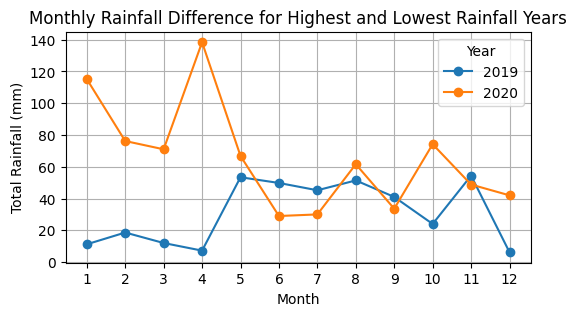

In [120]:
high_low_diff = top_3_years.iloc[0] - low_3_years.iloc[0]
print(f'Year {top_3_years.index[0]} has the highest total rainfall: {top_3_years.iloc[0]} mm')
print(f'Year {low_3_years.index[0]} has the lowest total rainfall: {low_3_years.iloc[0]} mm')
print(f'The difference between the highest and lowest total rainfall years: {high_low_diff} mm')

# Filter data for years 2019 & 2020
rain_2019_2020 = df[(df['Year'] == 2019) | (df['Year'] == 2020)]

# Monthly total rainfall (across years)
monthly_rainfall = rain_2019_2020.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().reset_index() # Use .reset_index() to convert it into a DataFrame

# Pivot the data
monthly_rainfall_pivot = monthly_rainfall.pivot(index='Month', columns='Year', values='Rainfall amount (millimetres)')

# Create the plot
monthly_rainfall_pivot.plot(kind='line', marker='o', figsize=(6,3))
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
plt.title('Monthly Rainfall Difference for Highest and Lowest Rainfall Years')
plt.xticks(range(1, 13))  # Ensure x-axis shows months 1-12
plt.legend(title="Year")  # Add a legend for year differentiation
plt.grid(True)  # Add grid for readability
plt.show()


## Task 2.4 
Explore the changes of rainfall in ABC City in the last 10 years.

(3640, 4)


/var/folders/ps/y3jw1ysn15x1631155827z0m0000gn/T/ipykernel_2269/3596430797.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=rain_10_years['Year'].unique())


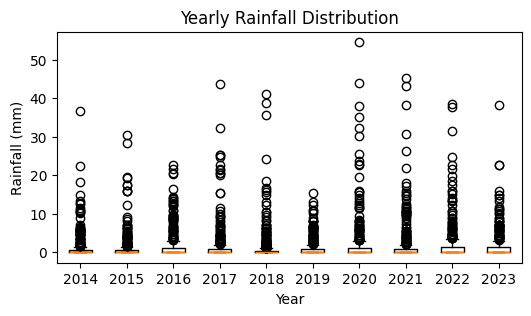

In [162]:
# 10 years data
rain_10_years = df[(df['Year'] >= 2014) & (df['Year'] <= 2023)]

# Prepare the data for boxplot
data = []
for year in rain_10_years['Year'].unique():
    rainfall_values = rain_10_years[rain_10_years['Year'] == year]['Rainfall amount (millimetres)']
    data.append(rainfall_values)

plt.figure(figsize=(6,3))
plt.boxplot(data, labels=rain_10_years['Year'].unique())
plt.title('Yearly Rainfall Distribution')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.show()

In [167]:
yearly_rainfall = rain_10_years.groupby('Year')['Rainfall amount (millimetres)'].sum()  
yearly_avg_rainfall = rain_10_years.groupby('Year')['Rainfall amount (millimetres)'].mean() 
print(yearly_rainfall)
print(yearly_avg_rainfall)


Year
2014    432.0
2015    439.2
2016    599.6
2017    602.0
2018    514.4
2019    374.4
2020    786.8
2021    682.6
2022    699.4
2023    574.0
Name: Rainfall amount (millimetres), dtype: float64
Year
2014    1.183562
2015    1.206593
2016    1.638251
2017    1.653846
2018    1.424931
2019    1.034254
2020    2.149727
2021    1.880441
2022    1.916164
2023    1.576923
Name: Rainfall amount (millimetres), dtype: float64


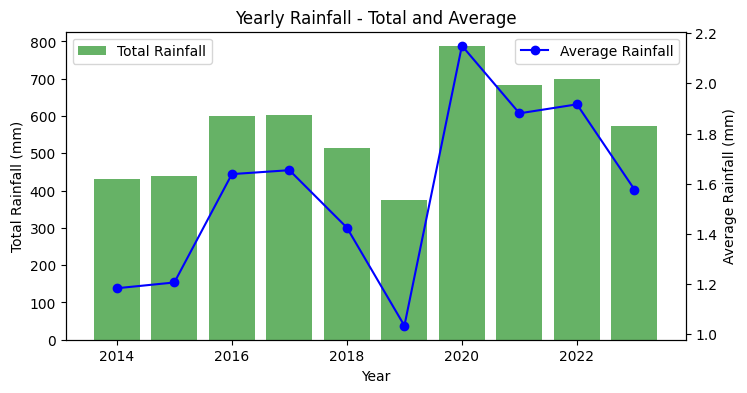

In [164]:
# Plot setup with two y-axes
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot the total rainfall (left y-axis) as a bar chart with explicit blue color
ax1.bar(yearly_rainfall.index, yearly_rainfall.values, color='green', alpha=0.6, label='Total Rainfall')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Rainfall (mm)')
ax1.tick_params(axis='y')
ax1.set_title('Yearly Rainfall - Total and Average')

# Create a second y-axis for the average rainfall (right y-axis)
ax2 = ax1.twinx()  
# Plot the average rainfall as a line with markers, using green color
ax2.plot(yearly_avg_rainfall.index, yearly_avg_rainfall.values, color='blue', marker='o', label='Average Rainfall', linestyle='-', markersize=6)
ax2.set_ylabel('Average Rainfall (mm)')
ax2.tick_params(axis='y')

# Add legends for both axes
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Display the plot
plt.xticks(rotation=90)
plt.show()

Month     1     2     3      4     5     6     7     8     9      10    11  \
Year                                                                         
2014    13.4  22.4  21.8   68.0  33.8  48.8  20.2  31.4  31.2   45.8  58.2   
2015    47.4  37.8  23.0   36.8  37.6  27.8  58.0  38.2  30.6   12.2  43.0   
2016    48.0   9.0  35.6   48.6  57.0  54.4  64.2  61.2  87.2   63.4  31.4   
2017    31.6  40.2  26.4  123.4  25.0  16.8  30.4  53.8  39.6   40.4  46.0   
2018    65.4   1.6  23.0   16.4  65.6  43.2  19.4  42.8  16.4   18.0  97.8   
2019    11.2  18.6  12.0    7.2  53.4  49.8  45.2  51.4  41.0   24.0  54.4   
2020   115.2  76.2  71.0  138.4  66.8  29.0  30.0  61.6  33.6   74.2  48.8   
2021    88.0   9.2  54.8   37.0  66.4  43.8  31.2  49.6  68.6  110.4  96.6   
2022    79.6   6.8  54.2   72.6  24.2  52.4  36.2  59.4  48.8  149.0  73.8   
2023    20.2  23.6  48.8  108.6  77.8  52.8  20.6  22.4  10.8   76.0  42.4   

Month     12  
Year          
2014    37.0  
2015    46.8  
201

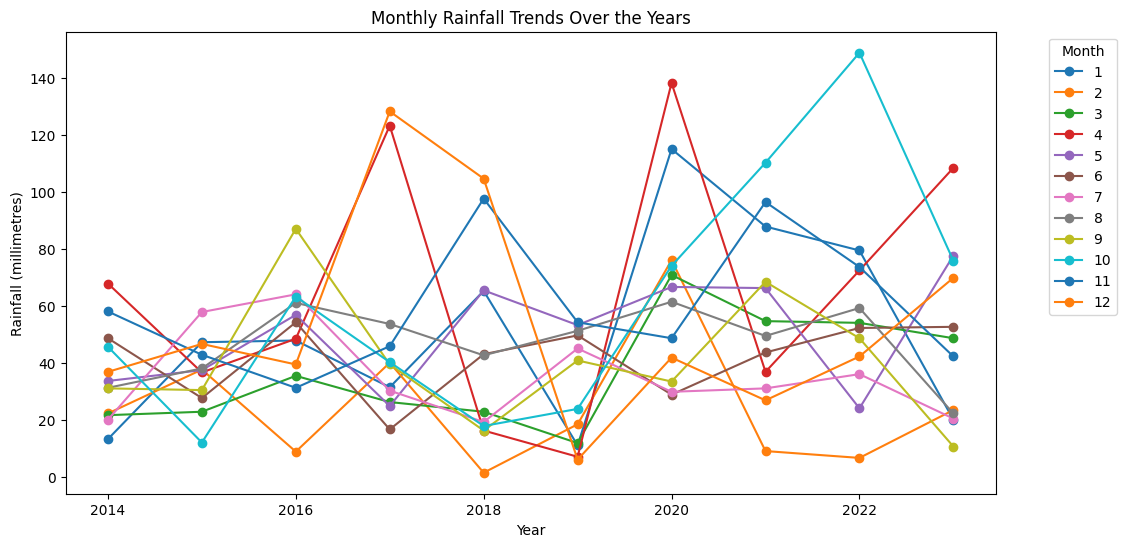

In [203]:
monthly_rainfall = rain_10_years.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().unstack()
print(monthly_rainfall)

monthly_rainfall.plot(marker='o', figsize=(12, 6))
plt.title('Monthly Rainfall Trends Over the Years')
plt.ylabel('Rainfall (millimetres)')
plt.xlabel('Year')
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


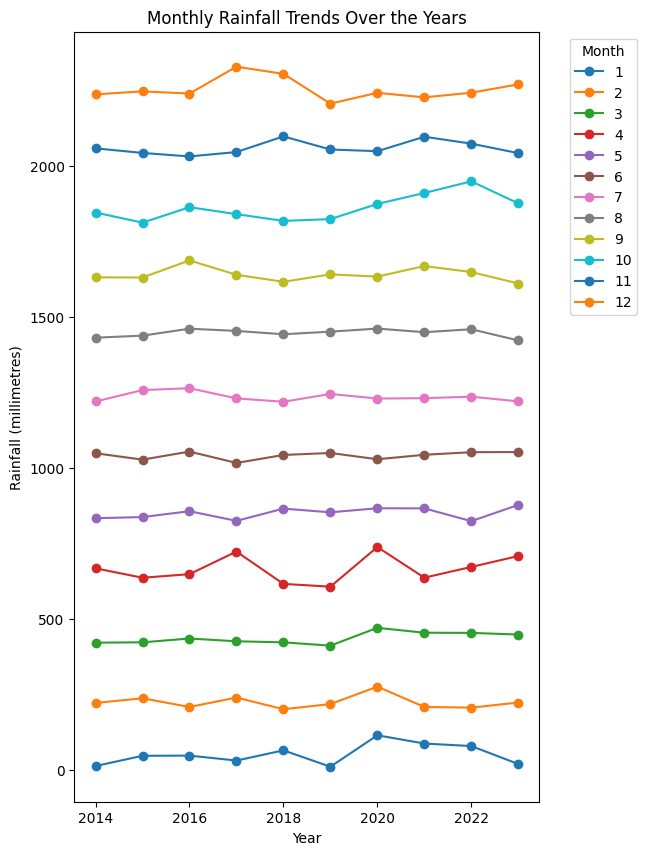

In [197]:
# Create a new DataFrame with adjusted values
adjusted_monthly_rainfall = monthly_rainfall.copy()

# Add 200, 400, 600,... to each column respectively
for i, column in enumerate(adjusted_monthly_rainfall.columns):
    adjusted_monthly_rainfall[column] = monthly_rainfall[column] + i * 200

adjusted_monthly_rainfall.plot(marker='o', figsize=(6, 10))
plt.title('Monthly Rainfall Trends Over the Years')
plt.ylabel('Rainfall (millimetres)')
plt.xlabel('Year')
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

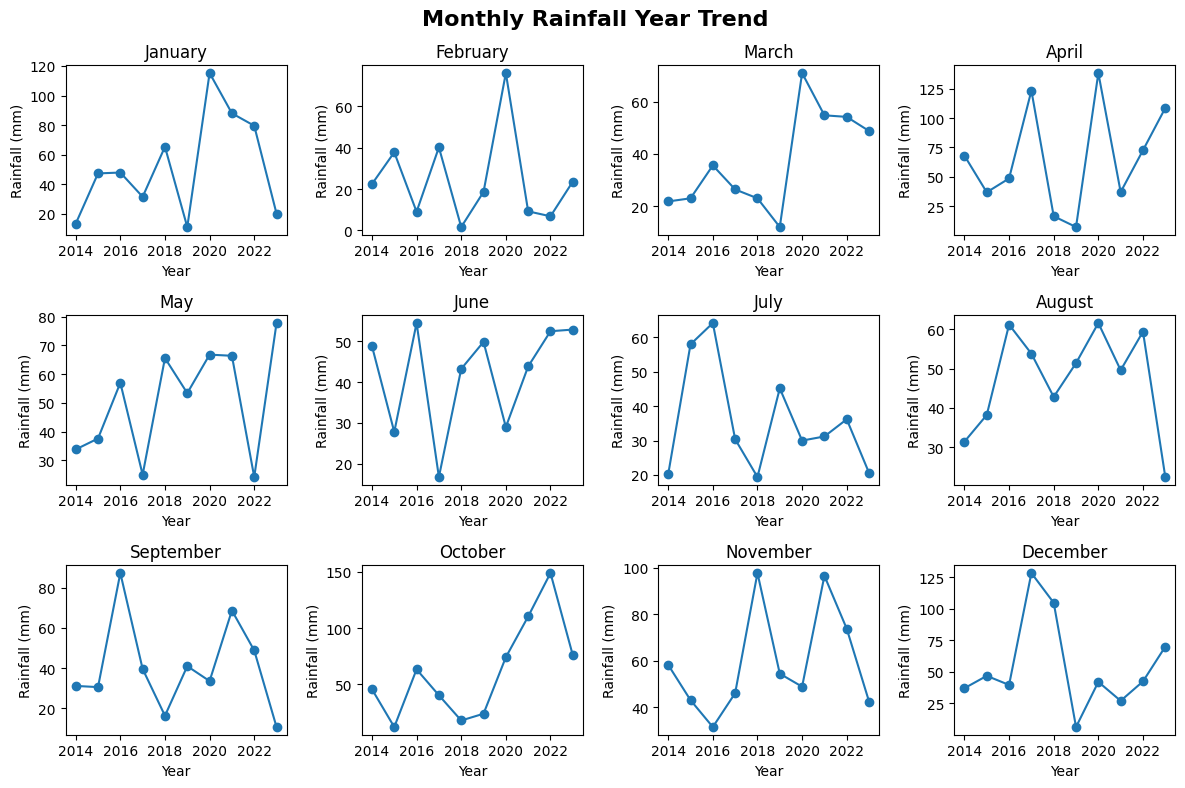

In [201]:
import calendar

# Get the months from the column names
months = monthly_rainfall.columns

plt.figure(figsize=(12, 8))  # Adjust figure size

# Add a main title for the entire figure
plt.suptitle("Monthly Rainfall Year Trend", fontsize=16, fontweight='bold')

# Loop through each month and plot it
for index, month in enumerate(months):
    plt.subplot(3, 4, index + 1)  # Define the grid layout for 3 rows and 4 columns
    plt.plot(monthly_rainfall.index, monthly_rainfall[month], marker='o') # Plot the year vs. rainfall for each month
    # plt.title(f'Month {month}')
    plt.title(f'{calendar.month_name[month]}')
    plt.xlabel('Year')
    plt.ylabel('Rainfall (mm)')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

Year   2014  2015  2016   2017   2018  2019   2020   2021   2022   2023
Month                                                                  
1      13.4  47.4  48.0   31.6   65.4  11.2  115.2   88.0   79.6   20.2
2      22.4  37.8   9.0   40.2    1.6  18.6   76.2    9.2    6.8   23.6
3      21.8  23.0  35.6   26.4   23.0  12.0   71.0   54.8   54.2   48.8
4      68.0  36.8  48.6  123.4   16.4   7.2  138.4   37.0   72.6  108.6
5      33.8  37.6  57.0   25.0   65.6  53.4   66.8   66.4   24.2   77.8
6      48.8  27.8  54.4   16.8   43.2  49.8   29.0   43.8   52.4   52.8
7      20.2  58.0  64.2   30.4   19.4  45.2   30.0   31.2   36.2   20.6
8      31.4  38.2  61.2   53.8   42.8  51.4   61.6   49.6   59.4   22.4
9      31.2  30.6  87.2   39.6   16.4  41.0   33.6   68.6   48.8   10.8
10     45.8  12.2  63.4   40.4   18.0  24.0   74.2  110.4  149.0   76.0
11     58.2  43.0  31.4   46.0   97.8  54.4   48.8   96.6   73.8   42.4
12     37.0  46.8  39.6  128.4  104.8   6.2   42.0   27.0   42.4

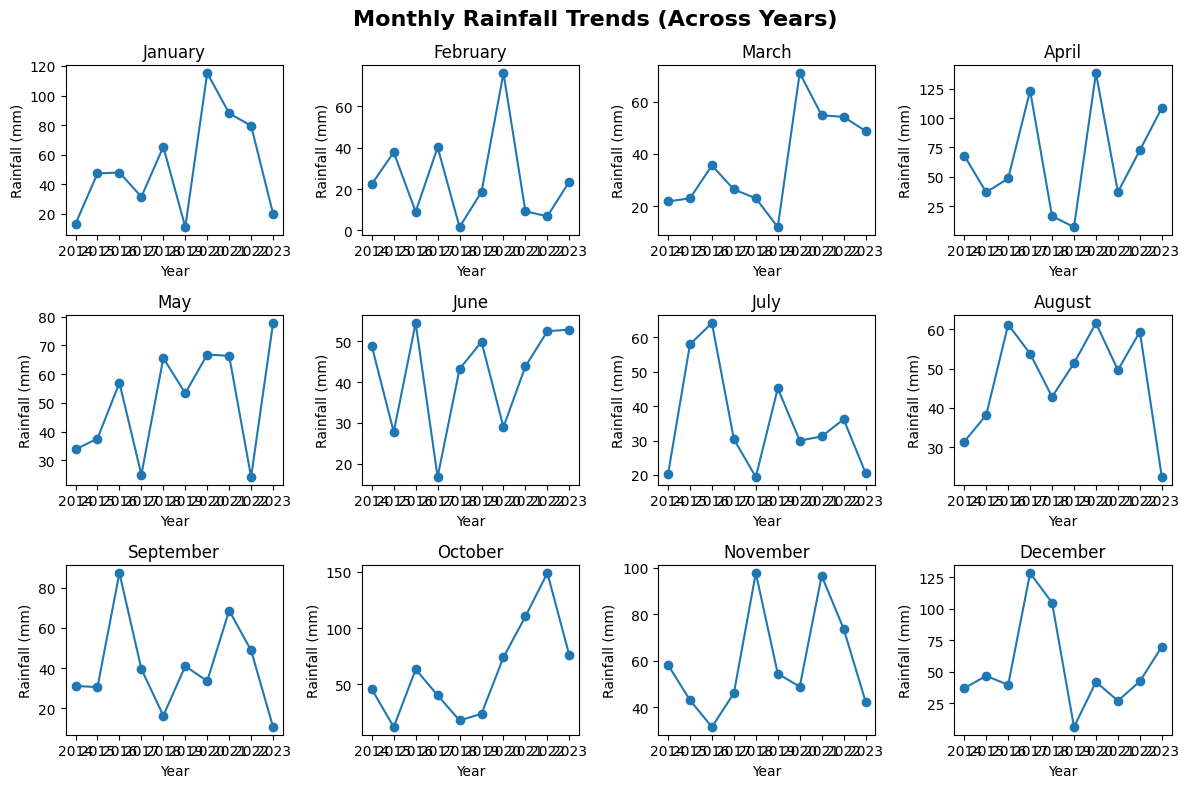

In [ ]:
import calendar
# monthly_rainfall = rain_10_years.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().unstack()
# print(monthly_rainfall)

monthly_rainfall_df = rain_10_years.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().reset_index()

# Pivot the data
monthly_rainfall_pivot = monthly_rainfall_df.pivot(index='Month', columns='Year', values='Rainfall amount (millimetres)')

# Create a figure with a grid layout for the subplots
plt.figure(figsize=(12, 8))  # Adjust figure size

# Add a main title for the entire figure
plt.suptitle("Monthly Rainfall Trends (Across Years)", fontsize=16, fontweight='bold')

# Loop through each month (rows) and plot it in the 3x4 grid
for index, month in enumerate(monthly_rainfall_pivot.index):
    plt.subplot(3, 4, index + 1)  # Define the grid layout (3 rows and 4 columns)
    
    # Plot the rainfall data for the current month
    plt.plot(monthly_rainfall_pivot.columns, monthly_rainfall_pivot.loc[month], marker='o', linestyle='-', markersize=6)
    
    # Set the title and labels
    plt.title(f'{calendar.month_name[month]}')  # Display month name (e.g., 'January', 'February')
    plt.xlabel('Year')
    plt.ylabel('Rainfall (mm)')
    
    # Set x-ticks to be the years
    plt.xticks(monthly_rainfall_pivot.columns)

# Adjust layout for better spacing
plt.tight_layout()  
plt.show()

In [214]:
import pandas as pd
from scipy.stats import f_oneway

# Grouping the data by Year and Month
monthly_rainfall_df = rain_10_years.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().reset_index()
# print(monthly_rainfall_df)
# Pivot the data: Rows are months, columns are years
monthly_rainfall_pivot = monthly_rainfall_df.pivot(index='Month', columns='Year', values='Rainfall amount (millimetres)')
print(monthly_rainfall_pivot)

# Perform ANOVA test for each month (row), apply the ANOVA test across the years (columns).
p_values = []

# Loop through each month (index 1-12)
for month in range(1, 13):
    # Extract the rainfall values for the given month (across all years)
    rainfall_values = monthly_rainfall_pivot.loc[month].values
    print(rainfall_values)
    
    # Perform ANOVA test for the given month (across all years)
    f_stat, p_value = f_oneway(*[rainfall_values])  # One-way ANOVA across years
    
    # Append the p-value for this month
    p_values.append(p_value)

# Add the p-values as a new column to the dataframe
monthly_rainfall_pivot['P-value'] = p_values

# Print the updated DataFrame with the p-values
print(monthly_rainfall_pivot)

Year   2014  2015  2016   2017   2018  2019   2020   2021   2022   2023
Month                                                                  
1      13.4  47.4  48.0   31.6   65.4  11.2  115.2   88.0   79.6   20.2
2      22.4  37.8   9.0   40.2    1.6  18.6   76.2    9.2    6.8   23.6
3      21.8  23.0  35.6   26.4   23.0  12.0   71.0   54.8   54.2   48.8
4      68.0  36.8  48.6  123.4   16.4   7.2  138.4   37.0   72.6  108.6
5      33.8  37.6  57.0   25.0   65.6  53.4   66.8   66.4   24.2   77.8
6      48.8  27.8  54.4   16.8   43.2  49.8   29.0   43.8   52.4   52.8
7      20.2  58.0  64.2   30.4   19.4  45.2   30.0   31.2   36.2   20.6
8      31.4  38.2  61.2   53.8   42.8  51.4   61.6   49.6   59.4   22.4
9      31.2  30.6  87.2   39.6   16.4  41.0   33.6   68.6   48.8   10.8
10     45.8  12.2  63.4   40.4   18.0  24.0   74.2  110.4  149.0   76.0
11     58.2  43.0  31.4   46.0   97.8  54.4   48.8   96.6   73.8   42.4
12     37.0  46.8  39.6  128.4  104.8   6.2   42.0   27.0   42.4

TypeError: At least two samples are required; got 1.